# notebook to train with sparse data and test with dense data

# setup

In [60]:
import network
import torch
import torch.nn as nn
import torch.nn.functional as F

# Unlike object, with SimpleNamespace you can add and remove attributes.
from types import SimpleNamespace 
import numpy as np
import random

# set the network size, to feed into the 1-layer network class

In [61]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # chooses the device for computation

m = 50 # input dimension
n = 100 # measurement dimension

# Set seed
seed = 1
network.set_random_mode(True, seed)

init_parameters = SimpleNamespace()
init_parameters.m = m 
init_parameters.n = n 
init_parameters.seed = seed

# the measurement matrix: randomly initialized
init_parameters.W = torch.randn(n,m).to(device)

# /torch.sqrt(torch.tensor(n)) 

store_image = True

[Random Mode] Deterministic with seed 1


## save the parameters (input-to-measurement weight matrix W)

In [62]:
import pickle
import os

weight_folder = f'weights/m_{m}_n_{n}_s_{seed}'
os.makedirs(weight_folder, exist_ok=True)

param_path = f'{weight_folder}/init_params.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(init_parameters, f)

# create the network

In [63]:
enose_network = network.enose(init_parameters)

#prints network parameters
print("input dimension: " + str(enose_network.m))
print("measurement dimension: " + str(enose_network.n))
print("input-to-measurement matrix: " + str(enose_network.W))

# print network architecture
for name, param in enose_network.named_parameters():
    print(f"{name}: {param.shape}")

input dimension: 50
measurement dimension: 100
input-to-measurement matrix: tensor([[-1.5256, -0.7502, -0.6540,  ..., -0.6298, -0.9274,  0.5451],
        [ 0.0663, -0.4370,  0.7626,  ...,  1.1899,  0.8165, -0.9135],
        [ 1.3851, -0.8138, -0.9276,  ...,  0.6419,  0.4730, -0.4286],
        ...,
        [-1.1080, -1.3766, -0.6012,  ..., -1.4471,  0.1287, -0.2051],
        [ 0.6614,  0.6542,  0.0522,  ..., -1.2430,  0.1239,  0.5274],
        [ 1.7035,  0.5626,  0.3812,  ..., -1.3296, -1.2682, -1.5542]],
       device='mps:0')
fc1.weight: torch.Size([1, 100])
fc1.bias: torch.Size([1])


In [64]:
# parameters
num_data=10000
sparse_training_frac=0.8
dense_training_frac=0.2
is_balanced=True
threshold=0.1
x_hat = threshold
num_training = int(num_data*sparse_training_frac)
bounds = (0,1)
sparsity_index = 45

# creates sparse dataset*

In [65]:
# creates sparse dataset, only training set
zero_dataset = network.generate_dataset(m, n, device, num_data, sparse_training_frac, is_balanced, threshold, bounds, sparsity_index)
zero_train_conc = zero_dataset.train_conc
zero_train_labels = zero_dataset.train_labels

# create dense dataset with bi-directional option*

In [67]:
# creates dense training dataset, only test set
nonzero_dataset = network.generate_dataset(m, n, device, num_data, dense_training_frac, is_balanced, threshold, bounds, None)
nonzero_test_conc = nonzero_dataset.test_conc
nonzero_test_labels = nonzero_dataset.test_labels
test_batch_size = 50


# initial accuracy
initial_accuracy = network.evaluate_random_batch(enose_network, nonzero_dataset, test_batch_size=20, threshold=0.1)
print(initial_accuracy)

0.6000000238418579


# optimize the parameters using cross entropy, save the trained weights

In [68]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(enose_network.parameters(), lr = 0.001)
lr = 0.001
batch_size = 10
steps = 10000
loss_vec = torch.zeros(steps)

test_interval = 50 # to make sure that all the test data are used multiple times
print_interval = 1000 # how often to print the accuracies and loss in terminal
test_batch_size = 20 
accuracy_vec = torch.zeros(steps // test_interval)

# train network on sparse dataset
loss_vec, accuracy_vec = network.train_model(
    enose_network,
    criterion,
    optimizer,
    lr,
    zero_train_conc,
    zero_train_labels,
    nonzero_test_conc,
    nonzero_test_labels,
    num_data,
    num_training,
    steps,
    batch_size,
    test_interval,
    print_interval,
    test_batch_size,
    device
)

# save the model weights
torch.save(enose_network.state_dict(), f"{weight_folder}/model_weights.pth")   

[Step 0] Accuracy: 0.5000 | Train Loss: 0.7702
[Step 1000] Accuracy: 0.8000 | Train Loss: 0.1678
[Step 2000] Accuracy: 0.6500 | Train Loss: 0.2305
[Step 3000] Accuracy: 0.8500 | Train Loss: 0.3220
[Step 4000] Accuracy: 0.9500 | Train Loss: 0.0879
[Step 5000] Accuracy: 0.7500 | Train Loss: 0.0324
[Step 6000] Accuracy: 0.9500 | Train Loss: 0.0549
[Step 7000] Accuracy: 0.7000 | Train Loss: 0.0483
[Step 8000] Accuracy: 0.5500 | Train Loss: 0.1497
[Step 9000] Accuracy: 0.7500 | Train Loss: 0.1820


## save mean accuracy, to compare with the accuracy after weight pertubation

In [69]:
# print accuracy vector    
accuracy_vec 

num_step = len(accuracy_vec)
mean_accuracy = torch.mean(accuracy_vec[num_step//2:-1])

param_path = f'{weight_folder}/mean_accuracy.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(mean_accuracy, f)
    
print(num_step)
mean_accuracy

200


tensor(0.7091)

# plot the training loss

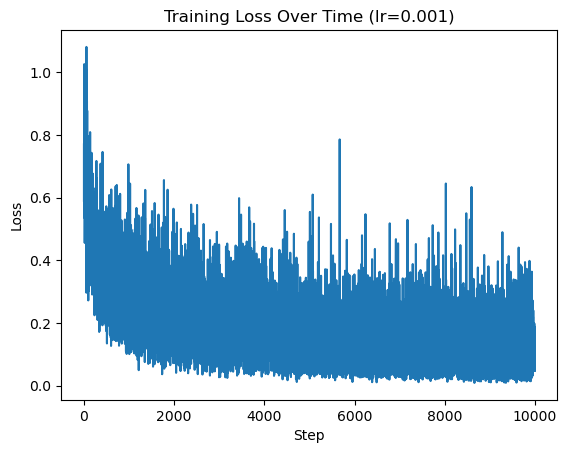

In [70]:
# Plot the loss curve and save (optional)
import matplotlib.pyplot as plt
import os

plt.plot(loss_vec)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Time (lr=" + str(lr) + ")")
# Make sure the folder exists
if store_image:
    folder = f'figures/m_{m}_n_{n}_s_{seed}'
    os.makedirs(folder, exist_ok=True)
    plt.savefig(f"{folder}/loss.pdf") 
plt.show()

# plot test accuracy

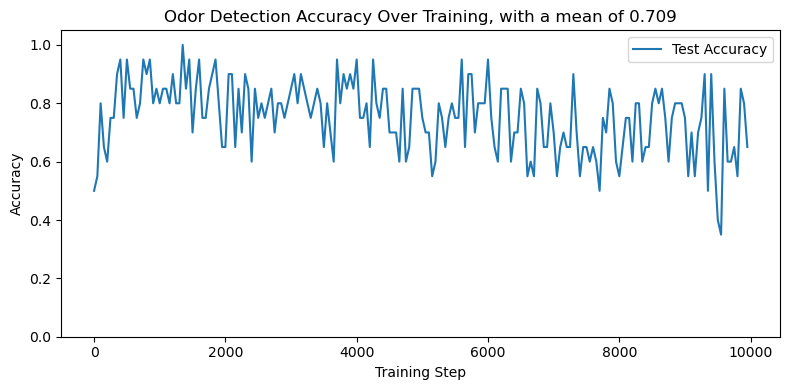

In [71]:
# Plot the test accuracy curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(torch.arange(0, steps, 50), accuracy_vec, label='Test Accuracy')
plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title(f"Odor Detection Accuracy Over Training, with a mean of {mean_accuracy:.3f}")
plt.ylim(0, 1.05)
# plt.grid(True)
plt.legend()
plt.tight_layout()
if store_image:
    plt.savefig(f"{folder}/accuracy.pdf")

plt.show()

# plot the weight matrices

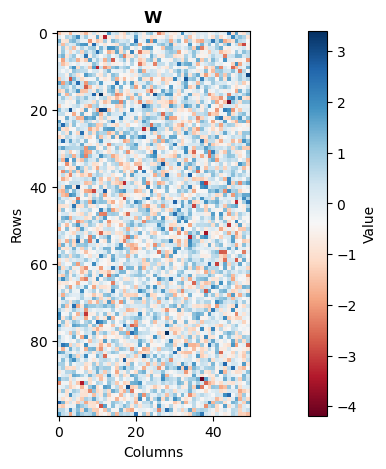

In [72]:
import torch
import matplotlib.pyplot as plt
W = enose_network.W.cpu().numpy()
# Plot using imshow
plt.figure(figsize=(15, 5))
plt.imshow(W, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W.pdf", bbox_inches='tight')
plt.show()

## plot the matrices

In [73]:
enose_network.fc1.bias

Parameter containing:
tensor([-0.2174], device='mps:0', requires_grad=True)

1
0.00912483


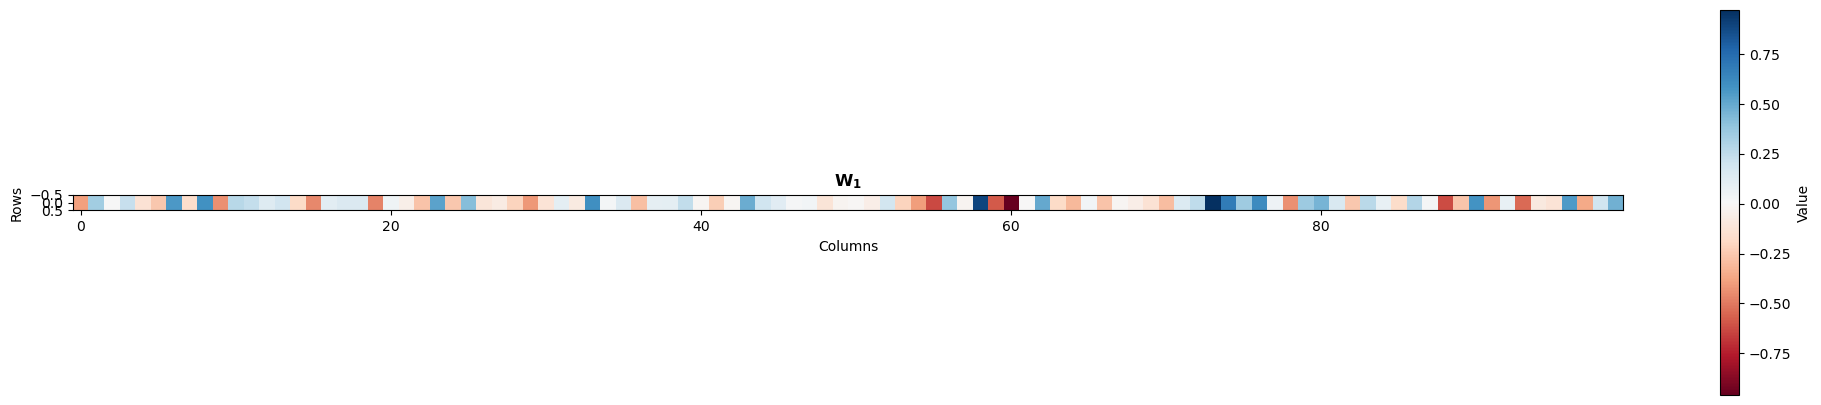

In [74]:
import torch
import matplotlib.pyplot as plt

W1 = enose_network.fc1.weight.detach().cpu().numpy()
b1 = enose_network.fc1.bias.detach().cpu().numpy()
print(b1.size)

W_h = W1 @ W
x1_hat_dagger = -b1[0]/W_h[0,0].item()
print(x1_hat_dagger)

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W1, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W1.pdf", bbox_inches='tight')
plt.show()

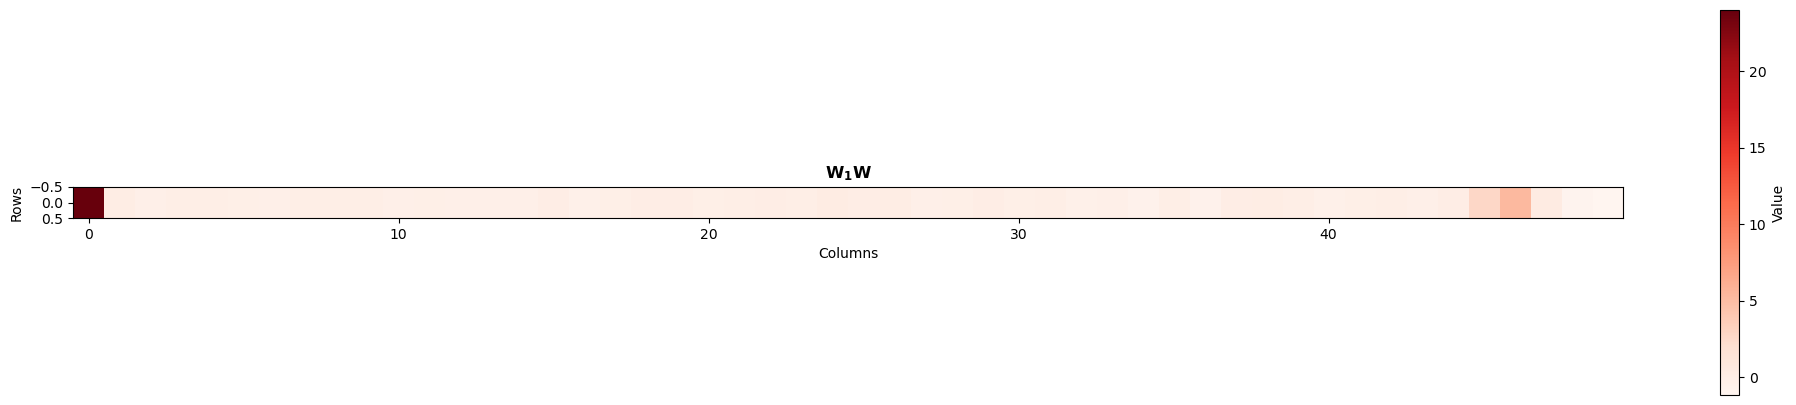

[ 2.40078430e+01  1.27562419e-01 -2.60132611e-01 -1.38433069e-01
 -8.77415836e-02 -1.69654563e-01 -2.82695919e-01 -1.60513580e-01
 -1.29790619e-01 -1.41045272e-01 -3.46872807e-01 -2.43588522e-01
 -3.44031155e-01 -3.55309278e-01 -3.03680271e-01  2.36765103e-04
 -4.43825692e-01 -1.83098555e-01 -4.00043093e-02 -1.97020490e-02
 -2.29421407e-01 -1.21478207e-01 -5.93173206e-02 -8.41527432e-02
  1.83791399e-01 -1.20667217e-03  7.89923742e-02 -3.20870191e-01
 -1.96668103e-01 -2.41028867e-03 -2.32361123e-01 -1.13907680e-01
 -4.13268477e-01 -3.31366122e-01 -5.88667095e-01 -9.61366743e-02
 -6.11030221e-01  2.92285737e-02  1.13505647e-01 -1.10834196e-01
 -4.22538549e-01 -1.64049402e-01 -7.64340609e-02 -2.71631628e-01
  3.16314325e-02  2.71887183e+00  5.29482365e+00  3.12949449e-01
 -8.77260745e-01 -1.14392459e+00]


In [57]:
import torch
import matplotlib.pyplot as plt

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W_h , cmap='Reds', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1 W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W_h.pdf")
# plt.savefig("figures/W_h.pdf")
plt.show()
plt.close()

# to verify that the first element dominates
print(W_h[0]) 

# plot the simplified 1-D curve, since the first element dominates

In [58]:
x_hat = threshold
print(x_hat)
print(x1_hat_dagger)

0.1
0.008758079


/var/folders/2w/xwcnb67d2wq2rf_47cyk6vpr0000gn/T/ipykernel_14714/3394132130.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = torch.sigmoid( W_h[0][0]*x + b1 )


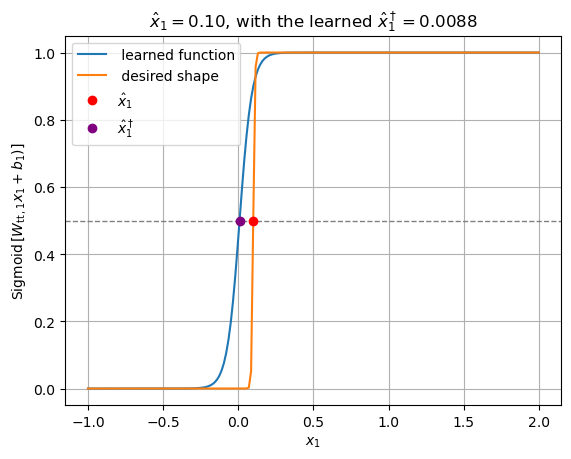

In [59]:
# x = torch.linspace(0, 1, 200)
x = torch.linspace(-1, 2, 200)

y = torch.sigmoid( W_h[0][0]*x + b1 )
y_2 = torch.sigmoid( 200*(x - x_hat) )
plt.plot(x, y, label =' learned function')
plt.plot(x, y_2, label = ' desired shape')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
plt.plot(x_hat, 0.5, 'o', color='red', label=r'$\hat{x}_1$')
plt.plot(x1_hat_dagger, 0.5, 'o', color='purple', label=r'$\hat{x}_1^\dagger$')


plt.title(fr'$\hat{{x}}_1 = {x_hat:.2f} $, with the learned $\hat{{x}}_1^\dagger = {x1_hat_dagger:.4f} $')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$\operatorname{Sigmoid}\left[ W_{\operatorname{tt},1} x_1 + b_1 ) \right]$')
plt.legend()
plt.grid(True)
if store_image:
    plt.savefig(f"{folder}/pickup_first_dim.pdf", bbox_inches='tight')
plt.show()